# Decathlon Revenue Risk Assessment — Audit Analytics
**Course activity: Collaborative Case-Based Learning with Reflection and Peer Discussion**

This notebook performs the revenue risk-assessment analytics for the integrated audit case study.
Data sources: `S_Data_KKL_Revenue_Report_19-21_1.xlsx` (transaction-level revenue ledger) and
`S_Data_Income_Statement_-_19-21.xlsx` (FY2019–FY2021 income statement).

**Materiality:** $2,000. **Priority area:** Revenue (this notebook). Inventory and Payroll are out of scope here.

---
### How to split this notebook between two teammates
| Person | Sections | Maps to rubric activity |
|---|---|---|
| **Teammate A** | 0 (Setup), 1 (Load & clean), 2 (Reconciliation), 3 (Trend/channel/country analytics) | Activity 1: Assess revenue account risk level |
| **Teammate B** | 4 (Data-quality & anomaly detection), 5 (Benford's Law + statistics), 6 (ReLU risk-scoring model) | Activity 3: Draft probing questions from anomalies |

Both of you run Section 0–1 first (5 min) so you're working off the same cleaned dataframe, then split.
Regroup after ~35 min to write Section 7 (consolidated memo) together — that's Activity 2, 4, 5 on the rubric.
Push this notebook + a plain `.py` export to GitHub when done (Section 8).

In [7]:
# SECTION 0 — Setup (run first, both teammates)
!pip -q install openpyxl scipy
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sstats
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi':120, 'font.size':11})

# In Colab: upload the two files when prompted, or mount Drive.
from google.colab import files
uploaded = files.upload()  # select S_Data_KKL_Revenue_Report_19-21_1.xlsx and S_Data_Income_Statement_-_19-21.xlsx


Saving S_Data_Income Statement - 19-21.xlsx to S_Data_Income Statement - 19-21.xlsx
Saving S_Data_KKL Revenue Report_19-21_1.xlsx to S_Data_KKL Revenue Report_19-21_1.xlsx


## SECTION 1 — Load & clean (Teammate A)
The raw revenue extract has two real data-quality issues you need to correct before any analysis
means anything — do NOT skip this step or your numbers won't match the income statement.

1. **56 fully blank rows** — an apparent export/system gap. Drop them.
2. **A column-shift error on ~99% of populated rows.** Wherever the `Invoice Num` column literally contains
   the text `"Sales"`, every field from `Accounts` onward has been shifted one column to the left
   (so `Company` holds the unit cost's old position, etc.). We detected this by profiling column dtypes —
   `Actual Standard Unit Cost` should be numeric but ~99% of rows had the string `"KeyKeyLime"` in it.
   The fix below shifts those fields back into their correct columns.

In [10]:
raw = pd.read_excel('S_Data_KKL Revenue Report_19-21_1.xlsx')
income_stmt = pd.read_excel('S_Data_Income Statement - 19-21.xlsx', header=None)
print("Raw shape:", raw.shape)

df = raw.dropna(subset=['Sales Amount']).copy()   # drop the 56 fully blank rows
n_blank = len(raw) - len(df)

shift_mask = df['Invoice Num'] == 'Sales'
print(f"Blank rows dropped: {n_blank}")
print(f"Rows affected by column-shift error: {shift_mask.sum()} of {len(df)} ({shift_mask.mean()*100:.1f}%)")

fixed = df.copy()
fixed.loc[shift_mask, 'Accounts']                  = 'Sales'
fixed.loc[shift_mask, 'Invoice Num']                = df.loc[shift_mask, 'Company']
fixed.loc[shift_mask, 'Company']                    = df.loc[shift_mask, 'Actual Standard Unit Cost']
fixed.loc[shift_mask, 'Actual Standard Unit Cost']  = df.loc[shift_mask, 'Actual Qty']
fixed.loc[shift_mask, 'Actual Qty']                 = df.loc[shift_mask, 'Sales Amount']
fixed.loc[shift_mask, 'Sales Amount']               = pd.to_numeric(df.loc[shift_mask, 'GL Posted Date'], errors='coerce')
fixed.loc[shift_mask, 'GL Posted Date']             = df.loc[shift_mask, 'Unnamed: 20']

for c in ['Sales Amount','Actual Qty','Actual Standard Unit Cost']:
    fixed[c] = pd.to_numeric(fixed[c], errors='coerce')

fixed['GL Posted Date'] = pd.to_datetime(fixed['GL Posted Date'], errors='coerce')
fixed['Shipped Date']   = pd.to_datetime(fixed['Shipped Date'], errors='coerce')

print("\nCleaned dataset ready:", fixed.shape)
fixed.head()

Raw shape: (2640, 21)
Blank rows dropped: 56
Rows affected by column-shift error: 2556 of 2584 (98.9%)

Cleaned dataset ready: (2584, 21)


,Fiscal Year,Qtr of Year,Fiscal Month,Ship Qtr Week,Shipped Date,Customer ID,Sales Channel,Sales Rep ID,Store ID,Ship To Country,Product Type,Item Number,Specific Product ID,Accounts,Invoice Num,Company,Actual Standard Unit Cost,Actual Qty,Sales Amount,GL Posted Date,Unnamed: 20
2,2019,1,March,10.0,2019-03-08,6406.0,E-Commerce,1003847.0,61.0,US,accessories,AC,AC-1,Sales,100091,KeyKeyLime,4.21,1.0,10.31,2019-03-09,NaT
3,2019,2,April,17.0,2019-04-28,5227.0,Retail,1005782.0,168.0,IL,accessories,AC,AC-1,Sales,100127,KeyKeyLime,4.21,1.0,10.31,2019-05-04,NaT
4,2019,2,April,17.0,2019-04-28,6157.0,Retail,1005071.0,170.0,UK,accessories,AC,AC-1,Sales,100128,KeyKeyLime,4.21,1.0,10.31,2019-05-04,NaT
5,2019,2,April,17.0,2019-05-01,4278.0,E-Commerce,1004003.0,157.0,GM,accessories,AC,AC-1,Sales,100138,KeyKeyLime,4.21,1.0,10.31,2019-05-04,NaT
6,2019,2,April,17.0,2019-05-02,7644.0,E-Commerce,1004044.0,140.0,JP,accessories,AC,AC-1,Sales,100139,KeyKeyLime,4.21,1.0,10.31,2019-05-04,NaT


## SECTION 2 — Reconciliation to the income statement (Teammate A)
Directly supports **Activity 1: Assess revenue account risk level.** If the detail ledger doesn't tie to
the income statement, that alone is a risk-assessment red flag (completeness/accuracy assertion).

      Ledger (per data extract)  Income Statement  Variance ($)  Variance %  \
2019                   28901.82          30311.29       1409.47        4.65   
2020                   27832.28          27832.28          0.00        0.00   
2021                   35107.23          35920.27        813.04        2.26   

      > Materiality?  
2019           False  
2020           False  
2021           False  


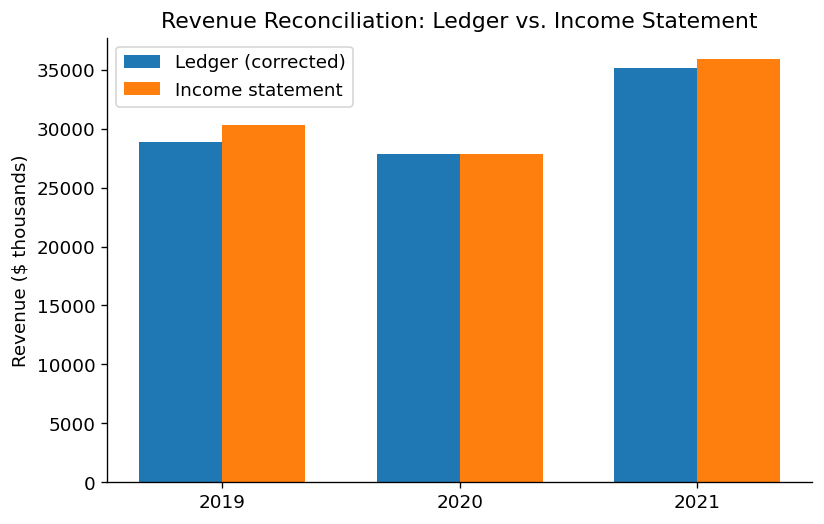

In [11]:
# SECTION 2 — Reconciliation
ledger_by_year = fixed.groupby('Fiscal Year')['Sales Amount'].sum().round(2)

# income_stmt sheet: row with year headers is row index 4, revenue row index 6 (0-indexed) per the template
is_years = [2021, 2020, 2019]
is_revenue = income_stmt.iloc[6, [2,4,6]].astype(float).tolist()
is_series = pd.Series(dict(zip(is_years, is_revenue))).sort_index()

recon = pd.DataFrame({'Ledger (per data extract)': ledger_by_year, 'Income Statement': is_series})
recon['Variance ($)'] = (recon['Income Statement'] - recon['Ledger (per data extract)']).round(2)
recon['Variance %'] = (recon['Variance ($)'] / recon['Income Statement'] * 100).round(2)
MATERIALITY = 2000
recon['> Materiality?'] = recon['Variance ($)'].abs() > MATERIALITY
print(recon)

fig, ax = plt.subplots(figsize=(7,4.5))
x = np.arange(len(recon)); w = 0.35
ax.bar(x-w/2, recon['Ledger (per data extract)'], w, label='Ledger (corrected)')
ax.bar(x+w/2, recon['Income Statement'], w, label='Income statement')
ax.set_xticks(x); ax.set_xticklabels(recon.index)
ax.set_ylabel('Revenue ($ thousands)'); ax.set_title('Revenue Reconciliation: Ledger vs. Income Statement')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## SECTION 3 — Trend, channel, product & geographic analytics (Teammate A)
These are the "drill-deeper" analytic visualizations the case study asks for, to give the engagement
team fact-based evidence behind the revenue balance.

Fiscal Year
2019    28901.82
2020    27832.28
2021    35107.23
Name: Sales Amount, dtype: float64 

YoY % change:
 Fiscal Year
2019          NaN
2020    -3.700597
2021    26.138534
Name: Sales Amount, dtype: float64


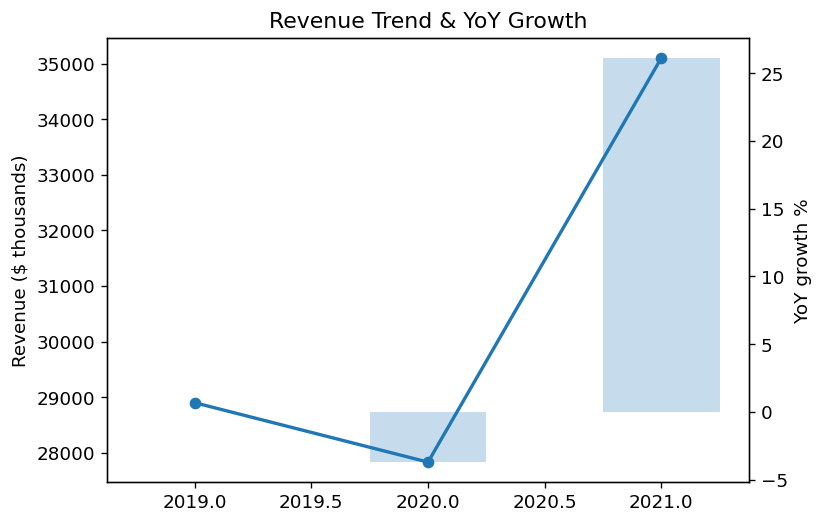

In [12]:
# SECTION 3a — YoY trend
years = sorted(fixed['Fiscal Year'].unique())
yearly = fixed.groupby('Fiscal Year')['Sales Amount'].sum()
yoy = yearly.pct_change() * 100
print(yearly, "\n\nYoY % change:\n", yoy)

fig, ax1 = plt.subplots(figsize=(7,4.5))
ax1.plot(yearly.index, yearly.values, marker='o', linewidth=2)
ax1.set_ylabel('Revenue ($ thousands)'); ax1.set_title('Revenue Trend & YoY Growth')
ax2 = ax1.twinx(); ax2.bar(yearly.index, yoy.fillna(0), alpha=0.25, width=0.5)
ax2.set_ylabel('YoY growth %')
plt.tight_layout(); plt.show()

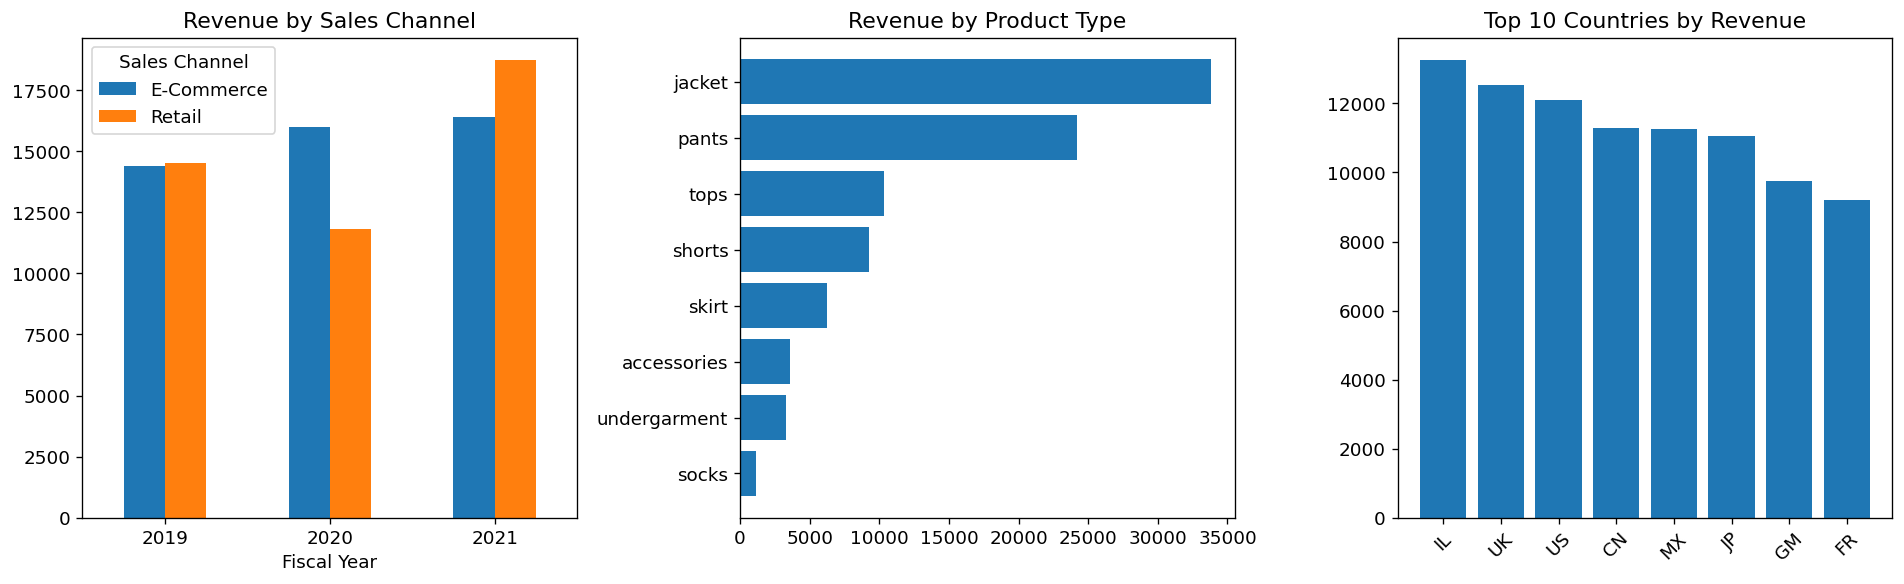

In [13]:
# SECTION 3b — Revenue by channel, product type, and country
fig, axes = plt.subplots(1, 3, figsize=(16,5))

fixed.groupby(['Fiscal Year','Sales Channel'])['Sales Amount'].sum().unstack().plot(kind='bar', ax=axes[0])
axes[0].set_title('Revenue by Sales Channel'); axes[0].tick_params(axis='x', rotation=0)

pt = fixed.groupby('Product Type')['Sales Amount'].sum().sort_values()
axes[1].barh(pt.index, pt.values); axes[1].set_title('Revenue by Product Type')

ctry = fixed.groupby('Ship To Country')['Sales Amount'].sum().sort_values(ascending=False).head(10)
axes[2].bar(ctry.index, ctry.values); axes[2].set_title('Top 10 Countries by Revenue')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

## SECTION 4 — Data-quality exceptions & cutoff testing (Teammate B)
Directly feeds **Activity 3: Draft probing client questions based on anomalies.**

In [14]:
# SECTION 4 — Data quality summary + cutoff test
missing_country = fixed['Ship To Country'].isna().sum()

fixed['ship_year'] = fixed['Shipped Date'].dt.year
cutoff_issue = fixed[fixed['ship_year'] != fixed['Fiscal Year']]
print("Rows where Shipped Date falls in a different calendar year than the Fiscal Year label:", len(cutoff_issue))
print(cutoff_issue['ship_year'].value_counts())
cutoff_issue[['Fiscal Year','Shipped Date','GL Posted Date','Sales Amount']].head(10)

Rows where Shipped Date falls in a different calendar year than the Fiscal Year label: 49
ship_year
2022    42
2020     4
2019     3
Name: count, dtype: int64


,Fiscal Year,Shipped Date,GL Posted Date,Sales Amount
115,2021,2022-08-13,2022-08-14,10.31
221,2021,2022-08-08,2022-08-14,13.48
308,2021,2022-08-12,2022-08-14,4.34
309,2021,2022-08-13,2022-08-14,4.34
310,2021,2022-08-13,2022-08-14,4.34
350,2020,2019-12-29,2020-01-04,72.09
426,2021,2022-08-09,2022-08-14,72.09
427,2021,2022-08-11,2022-08-14,72.09
428,2021,2022-08-13,2022-08-14,72.09
467,2020,2019-12-29,2020-01-04,56.26


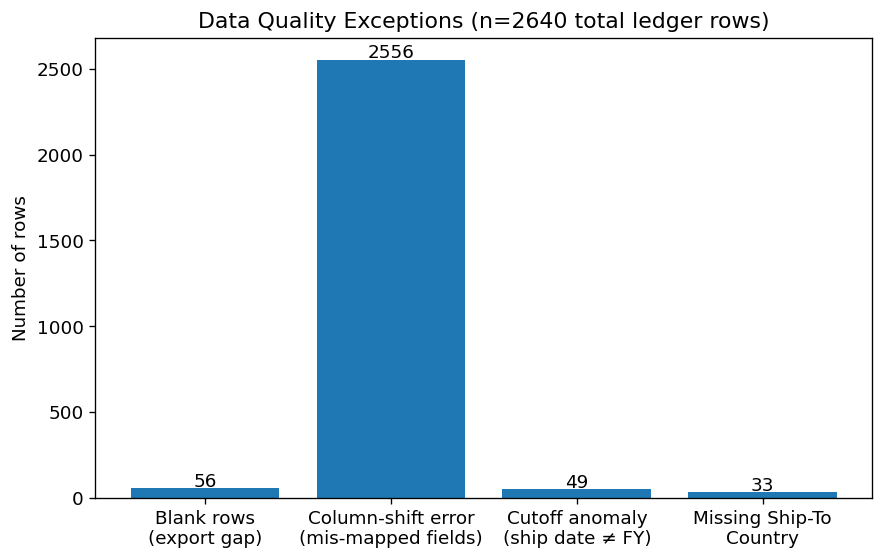

In [15]:
# SECTION 4b — quality-exceptions chart
labels = ['Blank rows\n(export gap)', 'Column-shift error\n(mis-mapped fields)',
          'Cutoff anomaly\n(ship date ≠ FY)', 'Missing Ship-To\nCountry']
vals = [n_blank, shift_mask.sum(), len(cutoff_issue), missing_country]
fig, ax = plt.subplots(figsize=(7.5,4.8))
ax.bar(labels, vals)
for i,v in enumerate(vals): ax.annotate(str(v), (i, v+10), ha='center')
ax.set_ylabel('Number of rows'); ax.set_title(f'Data Quality Exceptions (n={len(raw)} total ledger rows)')
plt.tight_layout(); plt.show()

## SECTION 5 — Statistical testing: Benford's Law + z-score outliers (Teammate B)
**Mathematical/statistical modelling component.** Two lightweight, explainable tests:

- **Benford's Law**: for naturally-occurring transaction amounts, the leading digit follows
  P(d) = log10(1 + 1/d). We run a chi-square goodness-of-fit test comparing observed vs. expected
  leading-digit frequencies. *Caveat (important for your memo):* Decathlon's sales amounts are
  unit-price × quantity with a small number of fixed price points, so some deviation from Benford's
  is expected from the business model itself, not necessarily manipulation — treat a significant
  chi-square result as a prompt for inquiry, not proof of misstatement.
- **Z-score outliers**: within each product type, flag any transaction whose Sales Amount is more
  than 3 standard deviations from that product type's mean.

Chi-square = 752.77, p-value = 0.0000  (n=2584)


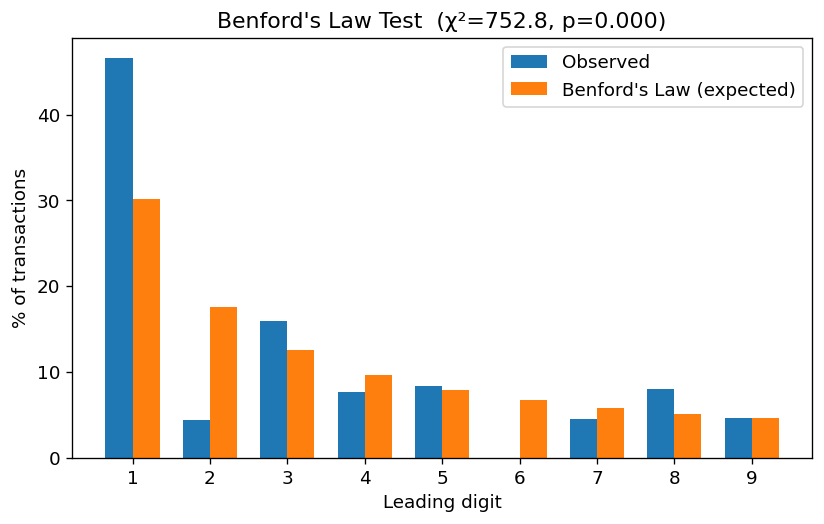

In [16]:
# SECTION 5a — Benford's Law
amt = fixed['Sales Amount'].dropna(); amt = amt[amt>0]
def first_digit(x):
    s = f'{x:.10f}'.lstrip('0').lstrip('.').lstrip('0')
    return int(s[0])
lead = amt.apply(first_digit)
digits = np.arange(1,10)
counts_obs = lead.value_counts().reindex(digits, fill_value=0)
expected_pct = np.log10(1+1/digits)
counts_exp = expected_pct*len(amt)
chi2_stat, p_val = sstats.chisquare(counts_obs, counts_exp)
print(f"Chi-square = {chi2_stat:.2f}, p-value = {p_val:.4f}  (n={len(amt)})")

fig, ax = plt.subplots(figsize=(7,4.5))
w=0.35
ax.bar(digits-w/2, counts_obs/len(amt)*100, w, label='Observed')
ax.bar(digits+w/2, expected_pct*100, w, label="Benford's Law (expected)")
ax.set_xticks(digits); ax.set_xlabel('Leading digit'); ax.set_ylabel('% of transactions')
ax.set_title(f"Benford's Law Test  (χ²={chi2_stat:.1f}, p={p_val:.3f})"); ax.legend()
plt.tight_layout(); plt.show()

24 transactions flagged with |z-score| > 3 (out of 2584)


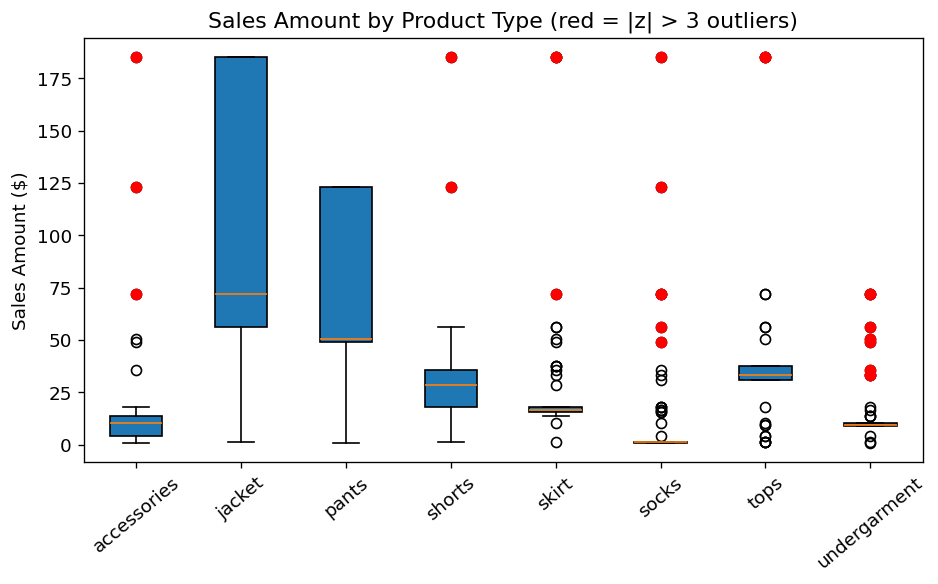

In [17]:
# SECTION 5b — Z-score outliers by product type
fixed['z'] = fixed.groupby('Product Type')['Sales Amount'].transform(lambda s: (s-s.mean())/s.std(ddof=0))
outliers = fixed[fixed['z'].abs() > 3]
print(f"{len(outliers)} transactions flagged with |z-score| > 3 (out of {fixed['Sales Amount'].notna().sum()})")

fig, ax = plt.subplots(figsize=(8,5))
types = sorted(fixed['Product Type'].dropna().unique())
data = [fixed[fixed['Product Type']==t]['Sales Amount'].dropna() for t in types]
ax.boxplot(data, tick_labels=types, patch_artist=True)
for t in types:
    o = outliers[outliers['Product Type']==t]['Sales Amount']
    if len(o): ax.scatter([types.index(t)+1]*len(o), o, color='red', zorder=5)
ax.set_ylabel('Sales Amount ($)'); ax.set_title('Sales Amount by Product Type (red = |z| > 3 outliers)')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout(); plt.show()

## SECTION 6 — Simple mathematical model: single-neuron ReLU risk score (Teammate B)
This is the "mathematical modelling" component your professor wants — kept deliberately small so the
whole team can understand it in ~15 minutes.

**The idea.** A single artificial neuron computes a *weighted sum* of standardized risk indicators,
then passes that sum through the **ReLU activation function**:

$$\text{ReLU}(x) = \max(0, x)$$

ReLU is the workhorse activation function in modern neural networks: it passes positive signal through
unchanged and zeroes out everything negative. Here that has a very literal audit meaning — we only
want a "risk score" for transactions that look unusual on the *positive* side (larger than normal),
and a score of exactly 0 for anything unremarkable.

**The model:**

$$\text{score} = \text{ReLU}\big(0.5\,z_{amount} + 0.3\,z_{qty} + 0.2\,z_{cost} - 1.5\big)$$

- $z_{amount}, z_{qty}, z_{cost}$ are z-scores (standardized values: how many standard deviations a
  transaction's amount/qty/unit-cost is from the dataset mean).
- The weights (0.5, 0.3, 0.2) reflect that unusually large **Sales Amount** is the strongest risk
  signal, quantity next, unit cost last — a judgment call you should state explicitly in your memo.
- The bias term **−1.5** is the threshold: a transaction needs to be collectively ~1.5 standard
  deviations "too high" across these weighted indicators before it gets flagged at all.
- This is mathematically one layer of a neural network (a single perceptron) — not a trained deep
  model — which is why it's explainable in one formula and one paragraph.

In [18]:
# SECTION 6 — Single-neuron ReLU risk-scoring model
d = fixed.dropna(subset=['Sales Amount','Actual Qty','Actual Standard Unit Cost']).copy()

def z(s): return (s - s.mean())/s.std(ddof=0)
d['z_amount'] = z(d['Sales Amount']); d['z_qty'] = z(d['Actual Qty']); d['z_cost'] = z(d['Actual Standard Unit Cost'])

w1, w2, w3, bias = 0.5, 0.3, 0.2, -1.5
linear_combo = w1*d['z_amount'] + w2*d['z_qty'] + w3*d['z_cost'] + bias
d['risk_score'] = np.maximum(0, linear_combo)          # <- this max(0, x) IS ReLU

flagged = d[d['risk_score'] > 0].sort_values('risk_score', ascending=False)
print(f"{len(flagged)} of {len(d)} transactions flagged ({len(flagged)/len(d)*100:.1f}%)")
flagged[['Fiscal Year','Product Type','Sales Channel','Sales Amount','Actual Qty','risk_score']].head(15)

132 of 2584 transactions flagged (5.1%)


,Fiscal Year,Product Type,Sales Channel,Sales Amount,Actual Qty,risk_score
563,2019,jacket,Retail,185.24,3.0,5.328465
487,2020,jacket,Retail,56.26,4.0,5.293708
2540,2019,undergarment,Retail,10.19,4.0,4.518972
2007,2019,tops,E-Commerce,33.09,3.0,2.769693
120,2019,accessories,Retail,13.48,3.0,2.419570
112,2021,accessories,E-Commerce,10.31,3.0,2.368408
1918,2019,socks,E-Commerce,1.26,3.0,2.227930
884,2019,pants,Retail,122.96,2.0,1.830021
647,2021,jacket,E-Commerce,185.24,1.0,1.043940
613,2020,jacket,E-Commerce,185.24,1.0,1.043940


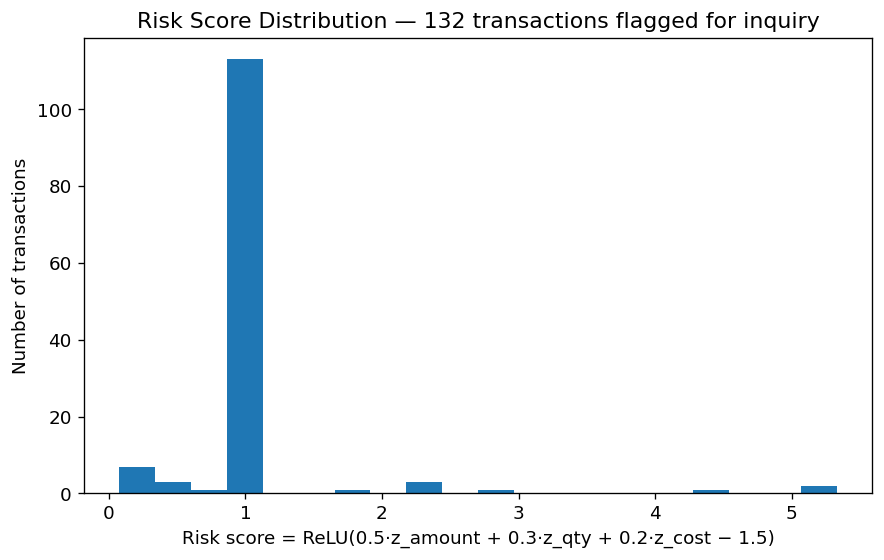

In [19]:
fig, ax = plt.subplots(figsize=(7.5,4.8))
ax.hist(flagged['risk_score'], bins=20)
ax.set_xlabel('Risk score = ReLU(0.5·z_amount + 0.3·z_qty + 0.2·z_cost − 1.5)')
ax.set_ylabel('Number of transactions')
ax.set_title(f'Risk Score Distribution — {len(flagged)} transactions flagged for inquiry')
plt.tight_layout(); plt.show()

In [20]:
# SECTION 7a — Pull every metric computed above into one summary table
summary_rows = [
    ("Reconciliation", "FY2019 ledger vs. income statement variance",
     f"${recon.loc[2019,'Variance ($)']:,.2f}  ({recon.loc[2019,'Variance %']:.2f}%)"),
    ("Reconciliation", "FY2020 ledger vs. income statement variance",
     f"${recon.loc[2020,'Variance ($)']:,.2f}  ({recon.loc[2020,'Variance %']:.2f}%)"),
    ("Reconciliation", "FY2021 ledger vs. income statement variance",
     f"${recon.loc[2021,'Variance ($)']:,.2f}  ({recon.loc[2021,'Variance %']:.2f}%)"),
    ("Data quality", "Fully blank rows in raw extract", f"{n_blank} of {len(raw)} ({n_blank/len(raw)*100:.1f}%)"),
    ("Data quality", "Rows affected by column-shift error", f"{shift_mask.sum()} of {len(df)} ({shift_mask.mean()*100:.1f}%)"),
    ("Data quality", "Missing Ship-To Country", f"{missing_country} rows"),
    ("Cutoff", "Transactions with Shipped Date outside stated Fiscal Year", f"{len(cutoff_issue)} rows"),
    ("Statistical testing", "Benford's Law chi-square test", f"χ²={chi2_stat:.1f}, p={p_val:.4f}"),
    ("Statistical testing", "Z-score outliers (|z|>3 within product type)", f"{len(outliers)} transactions"),
    ("Mathematical model", "ReLU risk-score model flags", f"{len(flagged)} of {len(d)} transactions ({len(flagged)/len(d)*100:.1f}%)"),
]
summary_df = pd.DataFrame(summary_rows, columns=["Category","Metric","Result"])
summary_df

,Category,Metric,Result
0,Reconciliation,FY2019 ledger vs. income statement variance,"$1,409.47 (4.65%)"
1,Reconciliation,FY2020 ledger vs. income statement variance,$0.00 (0.00%)
2,Reconciliation,FY2021 ledger vs. income statement variance,$813.04 (2.26%)
3,Data quality,Fully blank rows in raw extract,56 of 2640 (2.1%)
4,Data quality,Rows affected by column-shift error,2556 of 2584 (98.9%)
5,Data quality,Missing Ship-To Country,33 rows
6,Cutoff,Transactions with Shipped Date outside stated ...,49 rows
7,Statistical testing,Benford's Law chi-square test,"χ²=752.8, p=0.0000"
8,Statistical testing,Z-score outliers (|z|>3 within product type),24 transactions
9,Mathematical model,ReLU risk-score model flags,132 of 2584 transactions (5.1%)


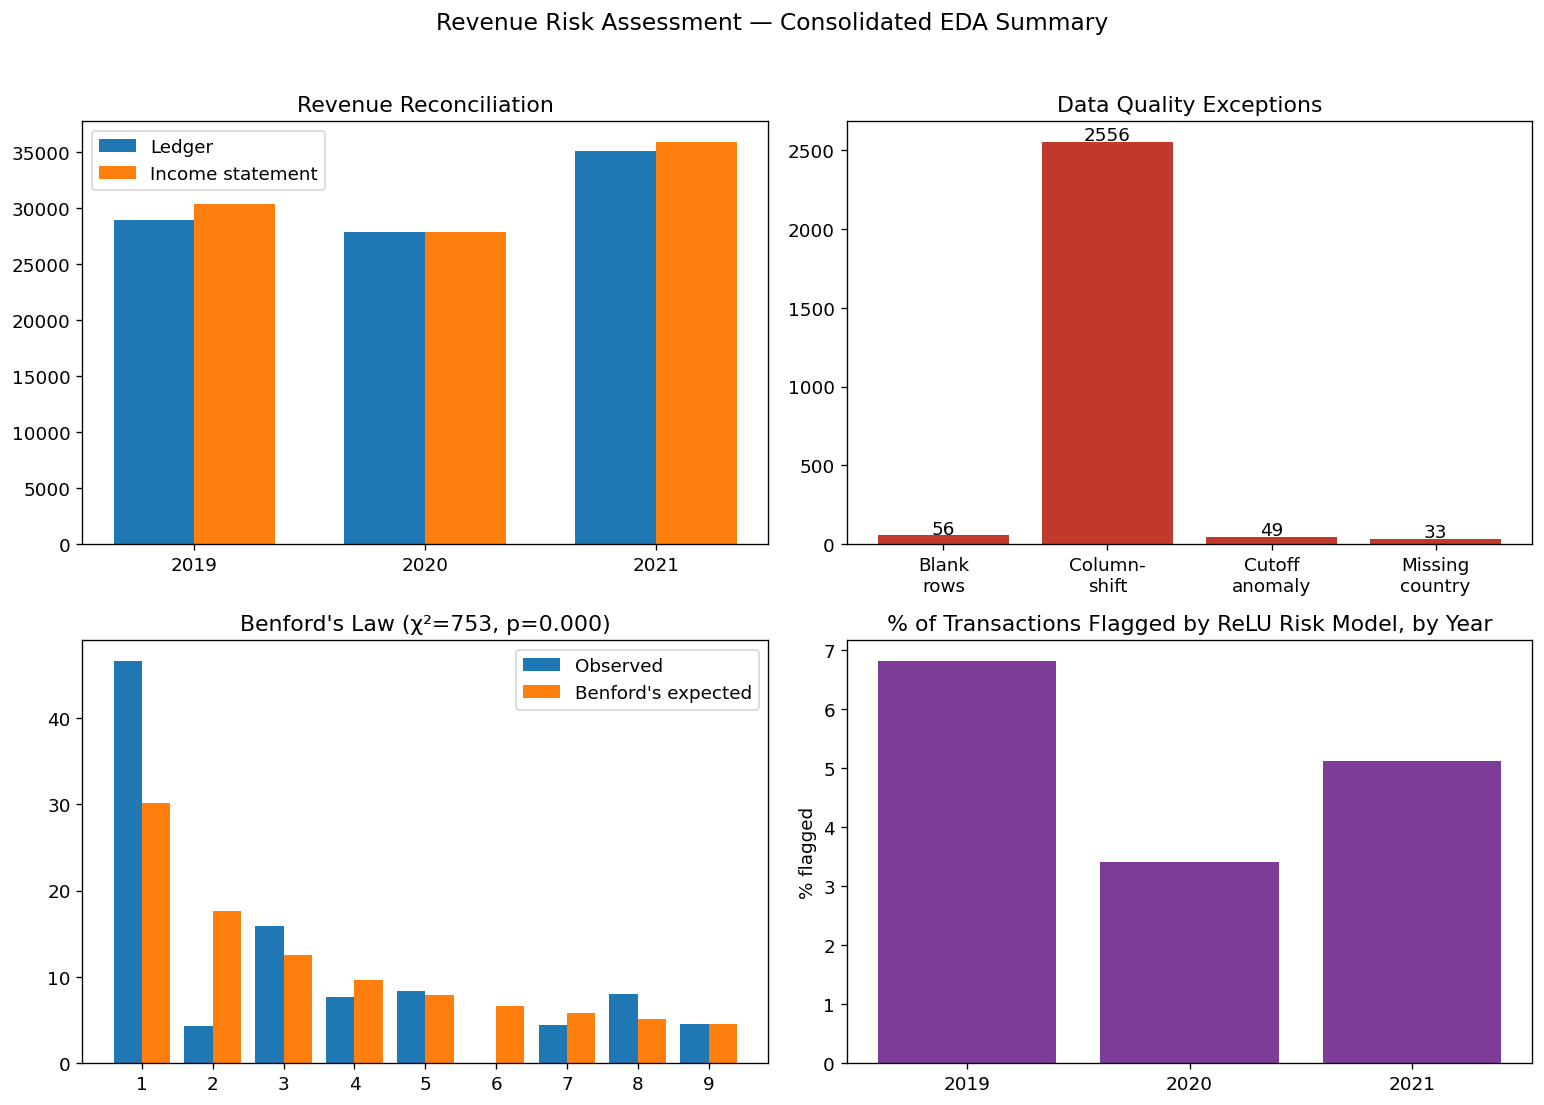

In [24]:
# SECTION 7b — Final EDA dashboard: one figure pulling the whole story together
fig, axes = plt.subplots(2, 2, figsize=(13,9))

# (1) Reconciliation
x = np.arange(len(recon)); w=0.35
axes[0,0].bar(x-w/2, recon['Ledger (per data extract)'], w, label='Ledger')
axes[0,0].bar(x+w/2, recon['Income Statement'], w, label='Income statement')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(recon.index)
axes[0,0].set_title('Revenue Reconciliation'); axes[0,0].legend()

# (2) Data quality exceptions
labels = ['Blank\nrows','Column-\nshift','Cutoff\nanomaly','Missing\ncountry']
vals = [n_blank, shift_mask.sum(), len(cutoff_issue), missing_country]
axes[0,1].bar(labels, vals, color='#c0392b')
axes[0,1].set_title('Data Quality Exceptions')
for i,v in enumerate(vals): axes[0,1].annotate(str(v), (i,v+10), ha='center')

# (3) Benford's Law
digits = np.arange(1,10)
axes[1,0].bar(digits-0.2, counts_obs/len(amt)*100, 0.4, label='Observed')
axes[1,0].bar(digits+0.2, expected_pct*100, 0.4, label="Benford's expected")
axes[1,0].set_title(f"Benford's Law (χ²={chi2_stat:.0f}, p={p_val:.3f})"); axes[1,0].legend()
axes[1,0].set_xticks(digits)

# (4) ReLU risk score flags by fiscal year
flag_by_year = flagged.groupby('Fiscal Year').size()
total_by_year = d.groupby('Fiscal Year').size()
flag_rate = (flag_by_year/total_by_year*100).reindex(total_by_year.index)
axes[1,1].bar(flag_rate.index.astype(str), flag_rate.values, color='#7d3c98')
axes[1,1].set_title('% of Transactions Flagged by ReLU Risk Model, by Year')
axes[1,1].set_ylabel('% flagged')

plt.suptitle('Revenue Risk Assessment — Consolidated EDA Summary', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()